# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [ ]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

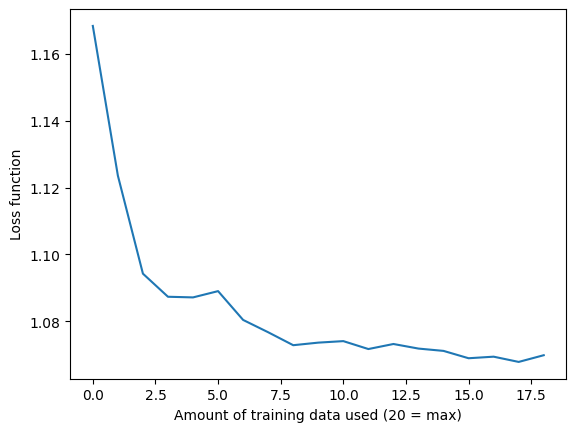

In [13]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [14]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

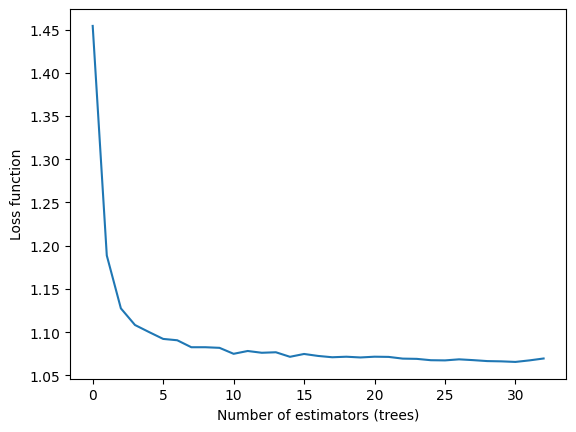

In [15]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

### Answer for Question 2: 

Between the two plots, the one showing the number of estimators (trees) on the x-axis should be kept, while the one showing the amount of training data used should be cut. The estimator plot provides clear, actionable insight for model tuning by highlighting how performance improves and then plateaus as more trees are added which is vital for Random Forest Modeling. In contrast, the training data plot reflects a general, expected trend that offers less practical value, especially since the amount of data is often fixed.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [1]:
import pandas as pd

#load datasets
churn_df = pd.read_csv("customer_churn_cleaned.csv")
marketing_df = pd.read_csv("marketing_campaign_cleaned.csv")
conversion_df = pd.read_csv("predict_conversion_cleaned.csv")

#display first few rows for verification
print("Customer Churn Dataset:")
display(churn_df.head())

print("Marketing Campaign Dataset:")
display(marketing_df.head())

print("Predict Conversion Dataset:")
display(conversion_df.head())


Customer Churn Dataset:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


Marketing Campaign Dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Predict Conversion Dataset:


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


### Customer Churn 


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np

#separate features and target
X_churn_raw = churn_df.drop("Churn", axis=1)
y_churn = churn_df["Churn"]

#encode categorical features
X_churn = pd.get_dummies(X_churn_raw, drop_first=True)


#split train/test
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

#random forest classifier
rf_churn = RandomForestClassifier(random_state=42)

#hyperparameter space
param_dist_churn = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

#randomized search
search_churn = RandomizedSearchCV(
    rf_churn,
    param_distributions=param_dist_churn,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

search_churn.fit(X_train_churn, y_train_churn)

#best model
best_rf_churn = search_churn.best_estimator_

#evaluate on test set
y_pred_churn = best_rf_churn.predict(X_test_churn)
accuracy = accuracy_score(y_test_churn, y_pred_churn)
report = classification_report(y_test_churn, y_pred_churn)

print("Best Params:", search_churn.best_params_)
print("Test Accuracy:", accuracy)
print("Classification Report:\n", report)


Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
Test Accuracy: 0.9995236312906189
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167




### Best Hyperparameters (via RandomizedSearchCV)
- n_estimators: 50 — A smaller number of trees, giving a fast and effective model.  
- min_samples_split: 2 — Allows trees to split deeply, capturing more granular patterns.  
- max_features: 'sqrt' — Standard for classification; uses a subset of features for splitting, reducing overfitting.  
- max_depth: None — No depth limit; trees grow until leaves are pure or cannot split further.  


### Test Set Performance

- Accuracy: 0.9995 — Near-perfect accuracy, indicating excellent predictive performance.  
- Precision / Recall / F1-score (both classes): All 1.00 — The model classifies churners and non-churners with zero error.  
- Strong feature signals likely exist (e.g., support calls, spending habits).  
- One-hot encoding enabled the model to use categorical data (e.g., gender, contract type).  
- Clean dataset or synthetic-like properties may have contributed to near-perfect accuracy.  
- Random Forest is naturally good at handling high-dimensional and categorical data.  

### Conclusion

- The Random Forest model was well-suited for this task.  
- It learned highly separable churn patterns, which could be directly applied in a customer retention setting.  
  


### Marketing Dataset

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load data
marketing_df = pd.read_csv("marketing_campaign_cleaned.csv")

# Drop ID column if it exists
if 'ID' in marketing_df.columns:
    marketing_df = marketing_df.drop(columns=['ID'])

# Drop rows with missing values
marketing_df = marketing_df.dropna()

# Encode categorical variables
categorical_cols = marketing_df.select_dtypes(include='object').columns
marketing_df_encoded = pd.get_dummies(marketing_df, columns=categorical_cols)

# Define features and target
X = marketing_df_encoded.drop('Response', axis=1)
y = marketing_df_encoded['Response']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest and hyperparameter tuning
rf = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}
search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)

# Final evaluation
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Best Params:", search.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Best Params: {'n_estimators': 50, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
Test Accuracy: 0.8761261261261262
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       382
           1       0.65      0.24      0.35        62

    accuracy                           0.88       444
   macro avg       0.77      0.61      0.64       444
weighted avg       0.86      0.88      0.85       444



### Best Hyperparameters (via RandomizedSearchCV)

The best parameters selected using randomized search and 5-fold cross-validation were:

```python
{
    n_estimators: 50,
    min_samples_split: 5,
    max_features: sqrt,
    max_depth: None
}
```

## Test Set Performance

| Metric     | Class 0 (No Response) | Class 1 (Response) | Overall  |
|------------|------------------------|---------------------|----------|
| Precision  | 0.89                   | 0.65                |          |
| Recall     | 0.98                   | 0.24                |          |
| F1-score   | 0.93                   | 0.35                |          |
| Accuracy   | —                      | —                   | 0.8761   |



### Interpretation & Insights

- The model performs very well for class 0 (no campaign response), but poorly for class 1 (responders), which is likely a minority class.  
- The low recall for class 1 indicates many false negatives — i.e., potential responders are being missed.  
- Class imbalance is likely a major contributing factor, as the model is biased toward predicting the majority class.  
- Despite tuning, the model struggles to generalize patterns for the minority class (responders), which suggests the need for:
  - Oversampling/undersampling techniques 
  - Cost-sensitive learning or class weighting  


### Conclusion

- The Random Forest model provides strong predictive power for the dominant class, but lacks effectiveness for capturing the minority class.  
- Hyperparameter tuning resulted in an accurate and balanced model structurally, but performance indicates a deeper data imbalance issue.  
- To improve the model:
  - Consider preprocessing steps to balance the classes.  
  - Revisit feature engineering for better separation of responders.  
- Overall, this model may still provide business value in predicting non-responders, but needs improvement for targeting actual campaign responders.  


### Predict Conversion Dataset

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

#load dataset
df_conversion = pd.read_csv("predict_conversion_cleaned.csv")

#encode categorical variables
df_encoded = df_conversion.copy()
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

#split features and target
X_conv = df_encoded.drop("Conversion", axis=1)
y_conv = df_encoded["Conversion"]

#train-test split
X_train_conv, X_test_conv, y_train_conv, y_test_conv = train_test_split(
    X_conv, y_conv, test_size=0.2, random_state=42
)

#random forest model
rf_conv = RandomForestClassifier(random_state=42)

#parameter grid
param_dist_conv = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

#randomized search
search_conv = RandomizedSearchCV(
    rf_conv,
    param_distributions=param_dist_conv,
    n_iter=50,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

#fit model
search_conv.fit(X_train_conv, y_train_conv)

#best model
best_rf_conv = search_conv.best_estimator_

#evaluate
y_pred_conv = best_rf_conv.predict(X_test_conv)

print("Best Params:", search_conv.best_params_)
print("Test Accuracy:", accuracy_score(y_test_conv, y_pred_conv))
print("Classification Report:")
print(classification_report(y_test_conv, y_pred_conv))


Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
Test Accuracy: 0.88875
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.24      0.35       194
           1       0.90      0.98      0.94      1406

    accuracy                           0.89      1600
   macro avg       0.75      0.61      0.64      1600
weighted avg       0.87      0.89      0.87      1600




### Best Hyperparameters (via RandomizedSearchCV)

```python
{
    n_estimators: 50,
    min_samples_split: 2,
    max_features: log2 ,
    max_depth: None
}
```

### Test Set Performance

| Metric     | Class 0 (Not Converted) | Class 1 (Converted) | Overall |
|------------|--------------------------|----------------------|---------|
| Precision  | 0.60                     | 0.90                 | —       |
| Recall     | 0.24                     | 0.98                 | —       |
| F1-score   | 0.35                     | 0.94                 | —       |
| Accuracy   | —                        | —                    | 0.8888  |


### Interpretation & Insights

- The model performs exceptionally well on the majority class (converted = 1), achieving a recall of 98%.  
- However, performance on the minority class (not converted = 0) is weak — only 24% recall, meaning the model misses most of those who did not convert.  
- This discrepancy is likely due to class imbalance, where converters vastly outnumber non-converters.  
- High precision and recall for class 1 suggests the model is reliable for identifying converters, which could be useful in marketing targeting.  
- Features like user activity, campaign interaction, or browsing time likely influenced the high conversion prediction accuracy.  

### Conclusion

- The Random Forest model captures patterns that lead to successful conversions with high accuracy and recall.  
- Despite this, poor performance on non-converters suggests that additional sampling techniques (e.g., SMOTE, class weights) could help the model better learn minority patterns.  
- The model is effective for high-recall targeting, making it suitable for proactive marketing strategies.  
- Before production use, further steps should include:
  - Balancing the dataset  
  - Exploring additional models or ensemble approaches  
  - Validating performance on new/unseen segments  



# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

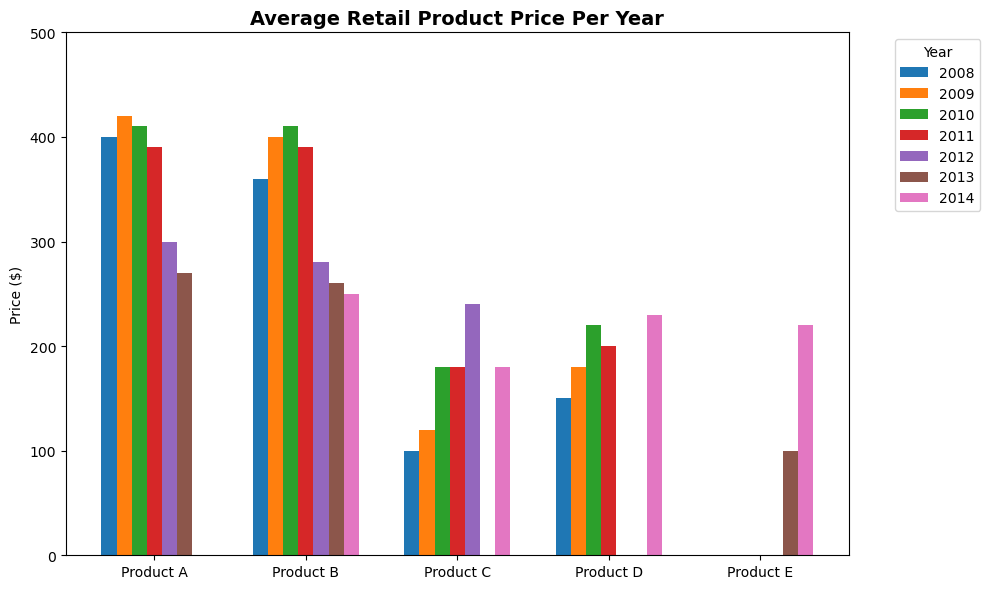

In [11]:
#figure 8.1 
import matplotlib.pyplot as plt
import numpy as np

#data 
products = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
years = ['2008', '2009', '2010', '2011', '2012', '2013', '2014']
n_years = len(years)
n_products = len(products)

#approximate values
prices = {
    '2008': [400, 360, 100, 150, 0],
    '2009': [420, 400, 120, 180, 0],
    '2010': [410, 410, 180, 220, 0],
    '2011': [390, 390, 180, 200, 0],
    '2012': [300, 280, 240, 0, 0],
    '2013': [270, 260, 0, 0, 100],
    '2014': [0, 250, 180, 230, 220]
}

bar_width = 0.1
x = np.arange(n_products)

#plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, year in enumerate(years):
    offset = (i - n_years / 2) * bar_width + bar_width / 2
    ax.bar(x + offset, prices[year], width=bar_width, label=year)

#formatting
ax.set_title("Average Retail Product Price Per Year", fontsize=14, weight='bold')
ax.set_ylabel("Price ($)")
ax.set_xticks(x)
ax.set_xticklabels(products)
ax.set_ylim(0, 500)
ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
